# 철강 표면 결함 분류 — 누적 최적화 실험

## 0. 환경 설정

In [40]:
import copy
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)

device: mps


## 1. 데이터 로드 및 분할

In [41]:
path = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")

data_root = Path(path) / "NEU-DET"
train_root = data_root / "train" / "images"
heldout_root = data_root / "validation" / "images"

class_names = sorted(folder.name for folder in train_root.iterdir() if folder.is_dir())
rng = np.random.default_rng(SEED)

train_samples, val_samples, test_samples = [], [], []
for class_id, class_name in enumerate(class_names):
    train_files = sorted((train_root / class_name).glob("*.jpg"))
    heldout_files = sorted((heldout_root / class_name).glob("*.jpg"))
    order = rng.permutation(len(heldout_files))

    val_samples.extend((heldout_files[i], class_id) for i in order[:30])
    test_samples.extend((heldout_files[i], class_id) for i in order[30:])
    train_samples.extend((file, class_id) for file in train_files)

print("classes:", class_names)
print("split  :", len(train_samples), len(val_samples), len(test_samples))

classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
split  : 1440 180 180


In [42]:
class SteelDefectDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        file, label = self.samples[index]
        image = Image.open(file).convert("L")
        return self.transform(image), label

## 2. 공통 헬퍼

- `add_sobel_channel` : 정규화 전 텐서(1,H,W)에 Sobel 경계 강도 채널을 붙여 (2,H,W) 로 만든다
- `build_transforms(sobel=, normalize=)` : 단계별 입력 파이프라인
- `compute_channel_stats` : train 셋에서 채널별 mean/std (정규화용, 누수 방지)

In [43]:
# Sobel 커널 (학습되지 않는 고정 필터)
SOBEL_X = torch.tensor([[-1.0, 0.0, 1.0],
                        [-2.0, 0.0, 2.0],
                        [-1.0, 0.0, 1.0]]).view(1, 1, 3, 3)
SOBEL_Y = torch.tensor([[-1.0, -2.0, -1.0],
                        [0.0, 0.0, 0.0],
                        [1.0, 2.0, 1.0]]).view(1, 1, 3, 3)


def add_sobel_channel(img):
    """img: (1, H, W) float in [0, 1]  ->  (2, H, W) = [원본, 경계강도]"""
    x = img.unsqueeze(0)  # (1, 1, H, W)
    gx = F.conv2d(x, SOBEL_X, padding=1)
    gy = F.conv2d(x, SOBEL_Y, padding=1)
    edge = torch.sqrt(gx ** 2 + gy ** 2).squeeze(0)  # (1, H, W)
    return torch.cat([img, edge], dim=0)  # (2, H, W)


def build_transforms(sobel=False, normalize=None):
    ops = [transforms.Resize((96, 96)), transforms.ToTensor()]
    if sobel:
        ops.append(transforms.Lambda(add_sobel_channel))
    if normalize is not None:
        ops.append(transforms.Normalize(*normalize))
    return transforms.Compose(ops)


def compute_channel_stats(transform, channels):
    """train 셋에서 채널별 mean/std 계산."""
    loader = DataLoader(SteelDefectDataset(train_samples, transform), batch_size=64)
    total = torch.zeros(channels)
    total_sq = torch.zeros(channels)
    count = 0
    for images, _ in loader:  # (B, C, H, W)
        total += images.sum(dim=[0, 2, 3])
        total_sq += (images ** 2).sum(dim=[0, 2, 3])
        count += images.shape[0] * images.shape[2] * images.shape[3]
    mean = total / count
    std = (total_sq / count - mean ** 2).sqrt()
    return tuple(mean.tolist()), tuple(std.tolist())

In [44]:
loss_fn = nn.CrossEntropyLoss()
RESULTS = []


def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = correct = count = 0

    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(images)
            correct += (outputs.argmax(1) == labels).sum().item()
            count += len(images)

    return total_loss / count, correct / count


def predict(model, loader):
    model.eval()
    answers, preds = [], []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            preds.extend(outputs.argmax(1).cpu().numpy())
            answers.extend(labels.numpy())
    return np.asarray(answers), np.asarray(preds)


def _to_disp(image):
    """(C,H,W) 텐서를 흑백 표시용 2D로. 2채널이면 원본(0번) 채널 사용."""
    if image.dim() == 3 and image.size(0) > 1:
        return image[0]
    return image.squeeze()


def plot_history(history, tag):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="train")
    plt.plot(epochs, history["val_loss"], marker="o", label="val")
    plt.title(f"{tag} - Loss")
    plt.xlabel("epoch")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker="o", label="train acc")
    plt.plot(epochs, history["val_acc"], marker="o", label="val acc")
    plt.plot(epochs, history["val_f1"], marker="o", label="val f1")
    plt.title(f"{tag} - Accuracy / F1")
    plt.xlabel("epoch")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()


def show_confusion(answers, preds, title):
    ConfusionMatrixDisplay.from_predictions(
        answers, preds, display_labels=class_names, cmap="Blues", xticks_rotation=35,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()


def show_predictions(model, dataset, n_per_class=2, title="Validation predictions"):
    model.eval()
    picks = []
    for class_id in range(len(class_names)):
        picks += [i for i, (_, label) in enumerate(dataset.samples) if label == class_id][:n_per_class]

    cols = n_per_class * 2
    rows = (len(picks) + cols - 1) // cols
    plt.figure(figsize=(3 * cols, 3 * rows))
    for position, data_index in enumerate(picks, start=1):
        image, answer = dataset[data_index]
        with torch.no_grad():
            pred = model(image.unsqueeze(0).to(device)).argmax(1).item()
        plt.subplot(rows, cols, position)
        plt.imshow(_to_disp(image), cmap="gray")
        color = "black" if pred == answer else "red"
        plt.title(f"T: {class_names[answer]}\nP: {class_names[pred]}", color=color, fontsize=9)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def _first_activation_layer(model):
    for module in model.modules():
        if isinstance(module, (nn.ReLU, nn.LeakyReLU, nn.GELU)):
            return module
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            return module
    return None


def show_feature_maps(model, image, max_maps=8, title="Feature maps"):
    layer = _first_activation_layer(model)
    store = {}
    handle = layer.register_forward_hook(
        lambda module, inputs, output: store.__setitem__("maps", output.detach().cpu())
    )
    model.eval()
    with torch.no_grad():
        model(image.unsqueeze(0).to(device))
    handle.remove()

    maps = store["maps"][0]
    count = min(max_maps, len(maps))
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 5, 1)
    plt.imshow(_to_disp(image), cmap="gray")
    plt.title("Input")
    plt.axis("off")
    for i in range(count):
        plt.subplot(2, 5, i + 2)
        plt.imshow(maps[i], cmap="viridis")
        plt.title(f"Map {i + 1}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [45]:
def train_eval(build_model, train_loader, val_loader, *, tag, epochs=15, lr=1e-3,
               optimizer_name="adam", weight_decay=0.0, use_scheduler=False):
    """한 실험을 학습하고 Validation 성능을 RESULTS에 기록 + 6종 진단 출력.

    build_model: 인자 없이 새 모델을 반환하는 함수 (예: lambda: BaselineCNN(1)).
    가중치 초기화가 시드 안에서 재현되도록 모델 생성을 여기서 한다.
    """
    set_seed(SEED)
    model = build_model().to(device)

    opt_cls = {"adam": torch.optim.Adam, "adamw": torch.optim.AdamW}[optimizer_name]
    optimizer = opt_cls(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        if use_scheduler else None
    )

    history = {k: [] for k in ["train_loss", "val_loss", "train_acc", "val_acc", "val_f1"]}
    best_val_loss, best_state = float("inf"), None  # Baseline과 동일한 선택 기준

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader)
        val_answers, val_preds = predict(model, val_loader)
        val_f1 = f1_score(val_answers, val_preds, average="macro")
        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        if val_loss < best_val_loss:  # Baseline: val_loss 최소 시점 복원
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch:02d} | train {train_loss:.3f}/{train_acc:.3f} | "
            f"val {val_loss:.3f}/{val_acc:.3f} | val_f1 {val_f1:.3f}"
        )

    model.load_state_dict(best_state)
    val_answers, val_preds = predict(model, val_loader)
    val_accuracy = accuracy_score(val_answers, val_preds)
    val_macro_f1 = f1_score(val_answers, val_preds, average="macro")

    Path("weights_report").mkdir(exist_ok=True)
    torch.save(best_state, f"weights_report/{tag}.pt")
    RESULTS.append({"tag": tag, "val_acc": round(val_accuracy, 4), "val_f1": round(val_macro_f1, 4),
                    "params": sum(p.numel() for p in model.parameters())})

    print(f"\n[{tag}] Val Accuracy = {val_accuracy:.4f} | Val Macro F1 = {val_macro_f1:.4f}")
    plot_history(history, tag)
    show_confusion(val_answers, val_preds, f"{tag} - Validation Confusion Matrix")
    show_predictions(model, val_loader.dataset, title=f"{tag} - Validation predictions")
    sample_image, _ = val_loader.dataset[0]
    show_feature_maps(model, sample_image, title=f"{tag} - Feature maps (first activation)")
    return model, history

## 3. 모델 정의

In [46]:
class BaselineCNN(nn.Module):
    """Baseline 구조: Conv 1블록 + 큰 FC. 입력 채널만 인자로 (E2에서 2채널)."""

    def __init__(self, in_channels=1):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 8, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 46 * 46, 32),
            nn.ReLU(),
            nn.Linear(32, 6),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class DeepCNN(nn.Module):
    """Conv 3블록 (3×3, padding=1 → 크기 유지) + 각 Conv 뒤 BatchNorm → FC.

    96 -> 48 -> 24 -> 12.  채널 진행 8 -> 16 -> 32.  FC 입력 = 32·12·12 = 4608 (dummy forward로 자동 계산).
    in_channels 는 첫 Conv 의 입력 채널만 결정한다 (Sobel 포함 시 2). 이후 채널 진행에는 영향 없음.
    """

    def __init__(self, in_channels=2, use_bn=True, channels=(8, 16, 32)):
        super().__init__()
        blocks = []
        prev = in_channels
        for channel in channels:
            blocks.append(nn.Conv2d(prev, channel, kernel_size=3, padding=1))
            if use_bn:
                blocks.append(nn.BatchNorm2d(channel))
            blocks.append(nn.ReLU())
            blocks.append(nn.MaxPool2d(kernel_size=2))
            prev = channel
        self.features = nn.Sequential(*blocks)

        with torch.no_grad():
            flat = self.features(torch.zeros(1, in_channels, 96, 96)).flatten(1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat, 32),
            nn.ReLU(),
            nn.Linear(32, 6),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

## 4. E0 — Baseline

Epoch 01 | train 1.568/0.305 | val 1.542/0.361 | val_f1 0.358
Epoch 02 | train 1.351/0.557 | val 1.514/0.339 | val_f1 0.314
Epoch 03 | train 1.199/0.560 | val 1.476/0.350 | val_f1 0.304
Epoch 04 | train 1.076/0.648 | val 1.394/0.378 | val_f1 0.369
Epoch 05 | train 1.020/0.622 | val 1.336/0.406 | val_f1 0.385
Epoch 06 | train 0.926/0.688 | val 1.266/0.461 | val_f1 0.464
Epoch 07 | train 0.912/0.674 | val 1.304/0.456 | val_f1 0.450
Epoch 08 | train 0.815/0.725 | val 1.110/0.517 | val_f1 0.507
Epoch 09 | train 0.772/0.737 | val 1.173/0.517 | val_f1 0.497
Epoch 10 | train 0.725/0.773 | val 1.129/0.578 | val_f1 0.549
Epoch 11 | train 0.664/0.794 | val 1.036/0.556 | val_f1 0.530
Epoch 12 | train 0.642/0.782 | val 1.101/0.550 | val_f1 0.525
Epoch 13 | train 0.608/0.802 | val 1.055/0.578 | val_f1 0.560
Epoch 14 | train 0.595/0.803 | val 1.115/0.567 | val_f1 0.547
Epoch 15 | train 0.549/0.827 | val 0.998/0.556 | val_f1 0.534

[E0_baseline] Val Accuracy = 0.5556 | Val Macro F1 = 0.5344


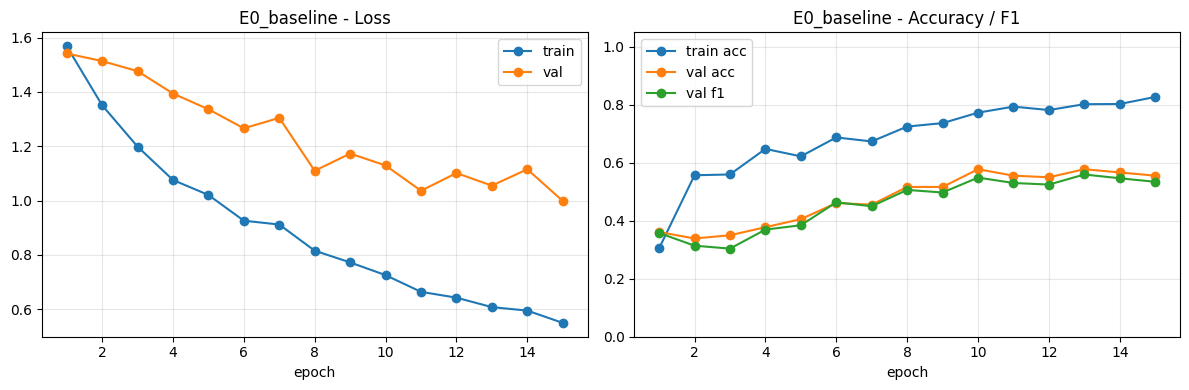

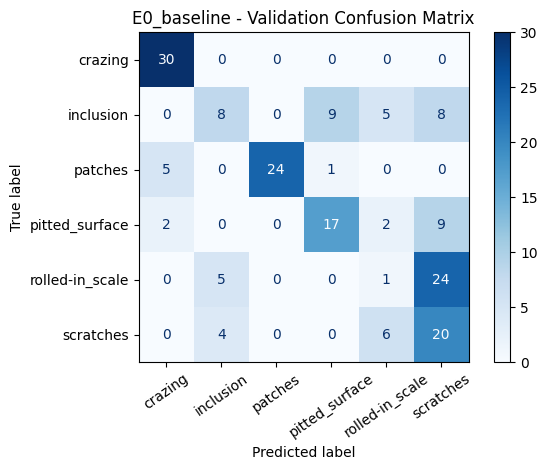

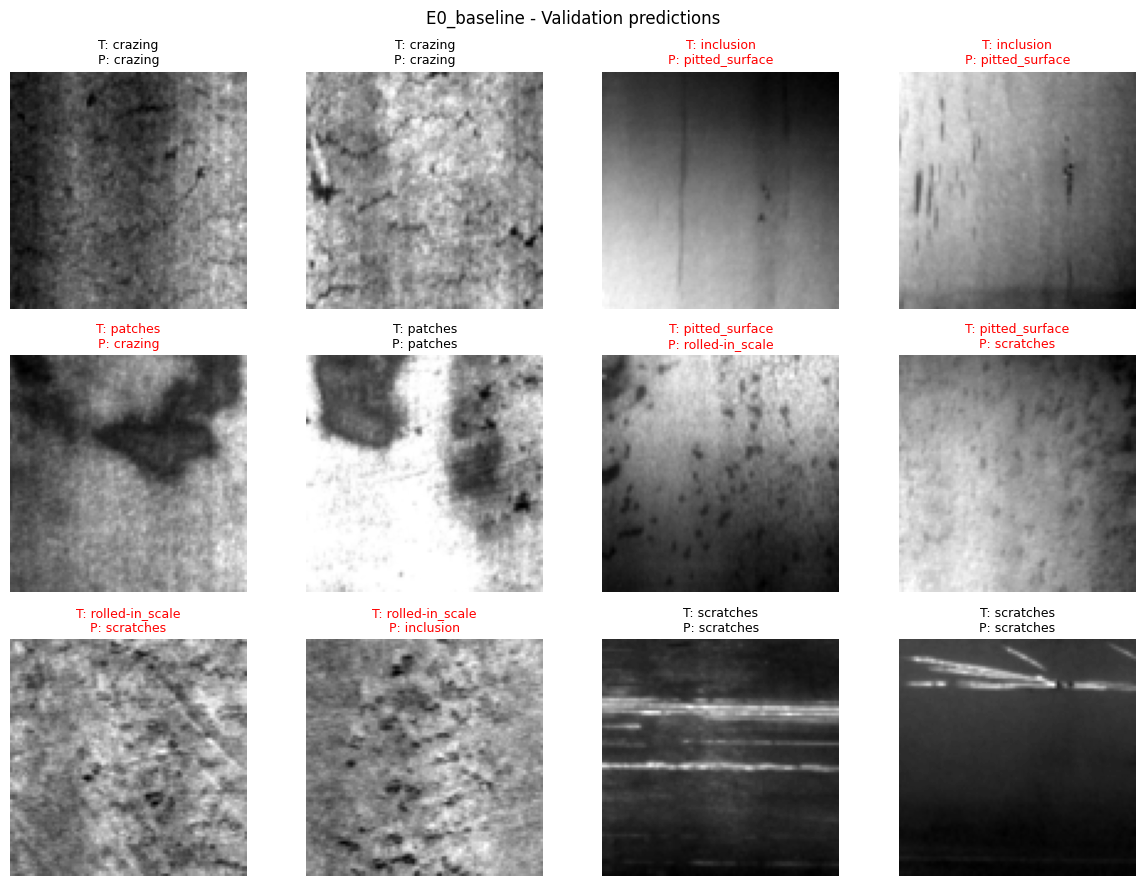

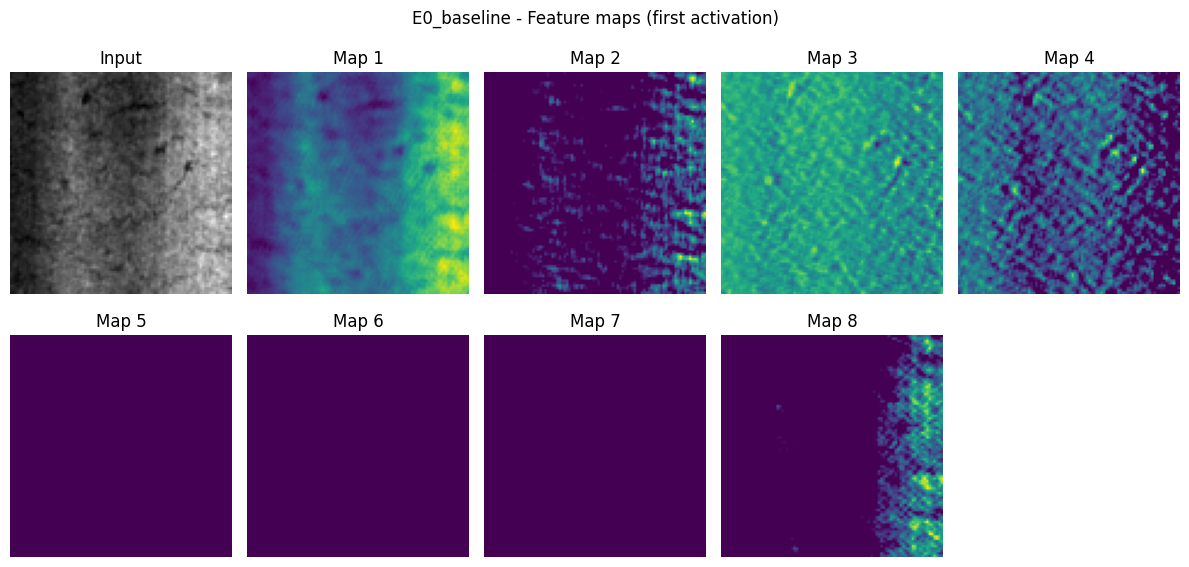

In [47]:
plain_tf = build_transforms()
train_loader = DataLoader(SteelDefectDataset(train_samples, plain_tf), batch_size=64, shuffle=True)
val_loader = DataLoader(SteelDefectDataset(val_samples, plain_tf), batch_size=64)
test_loader = DataLoader(SteelDefectDataset(test_samples, plain_tf), batch_size=64)

e0_model, _ = train_eval(lambda: BaselineCNN(in_channels=1), train_loader, val_loader, tag="E0_baseline", epochs=15)

## 5. E1 — + 정규화

- 확인 질문: 입력 분포 안정화가 도움이 되는가?
- 변경: `Normalize(train mean, std)` 추가

1채널 mean/std: ((0.5049790143966675,), (0.20541252195835114,))
Epoch 01 | train 1.497/0.385 | val 1.282/0.456 | val_f1 0.407
Epoch 02 | train 1.142/0.560 | val 1.107/0.517 | val_f1 0.436
Epoch 03 | train 0.869/0.691 | val 1.128/0.633 | val_f1 0.595
Epoch 04 | train 0.609/0.812 | val 0.863/0.622 | val_f1 0.628
Epoch 05 | train 0.550/0.813 | val 1.160/0.633 | val_f1 0.605
Epoch 06 | train 0.545/0.810 | val 1.005/0.594 | val_f1 0.547
Epoch 07 | train 0.411/0.868 | val 1.082/0.678 | val_f1 0.629
Epoch 08 | train 0.336/0.901 | val 0.662/0.744 | val_f1 0.742
Epoch 09 | train 0.317/0.899 | val 0.666/0.733 | val_f1 0.731
Epoch 10 | train 0.273/0.910 | val 0.782/0.633 | val_f1 0.611
Epoch 11 | train 0.257/0.919 | val 0.687/0.722 | val_f1 0.715
Epoch 12 | train 0.248/0.927 | val 0.852/0.678 | val_f1 0.666
Epoch 13 | train 0.278/0.912 | val 0.805/0.717 | val_f1 0.705
Epoch 14 | train 0.242/0.926 | val 0.597/0.783 | val_f1 0.776
Epoch 15 | train 0.239/0.926 | val 0.730/0.683 | val_f1 0.677

[E1_nor

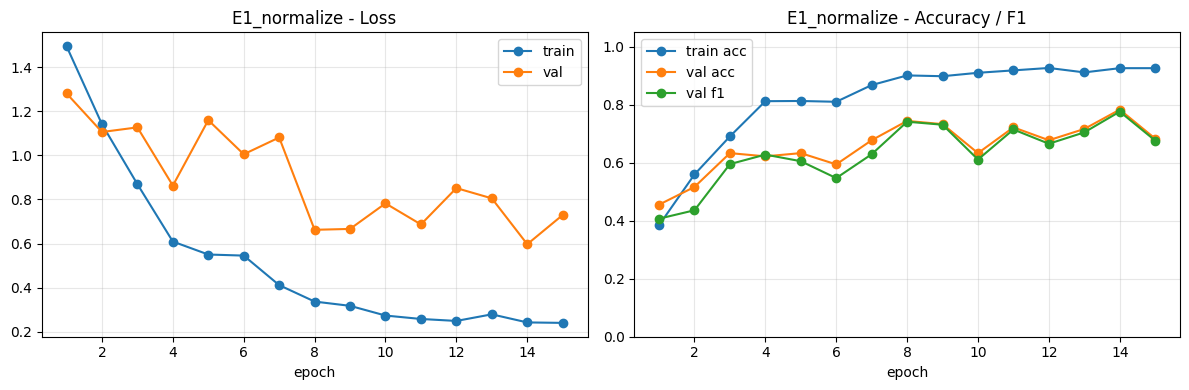

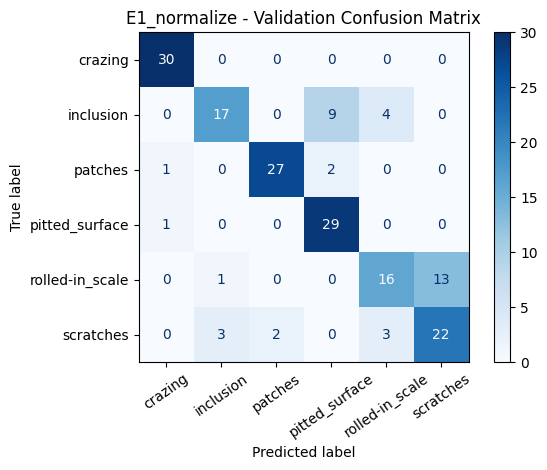

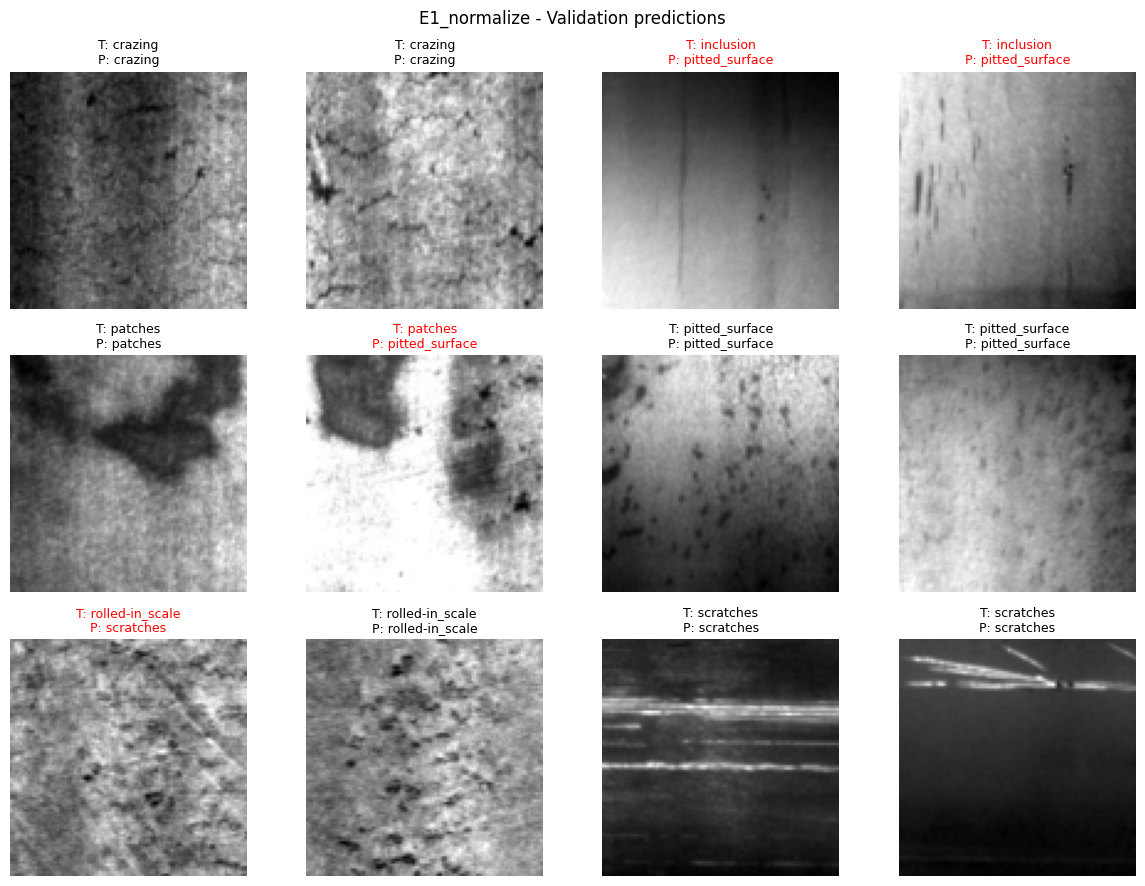

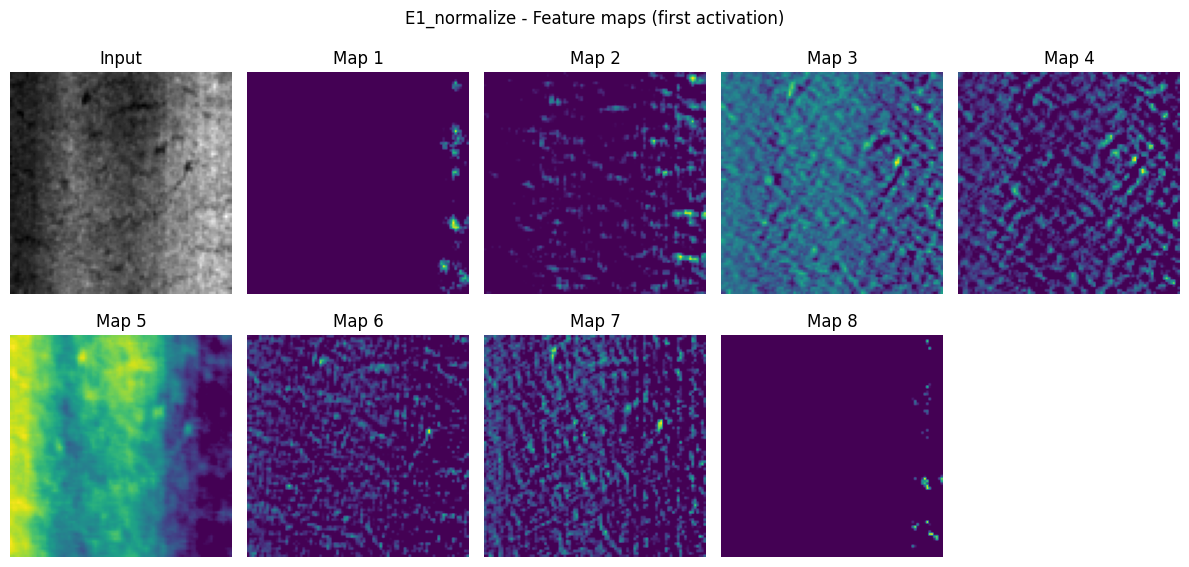

In [ ]:
NORM_1CH = compute_channel_stats(build_transforms(), channels=1)

norm_tf = build_transforms(normalize=NORM_1CH)
train_loader = DataLoader(SteelDefectDataset(train_samples, norm_tf), batch_size=64, shuffle=True)
val_loader = DataLoader(SteelDefectDataset(val_samples, norm_tf), batch_size=64)
test_loader = DataLoader(SteelDefectDataset(test_samples, norm_tf), batch_size=64)

e1_model, _ = train_eval(lambda: BaselineCNN(in_channels=1), train_loader, val_loader, tag="E1_normalize", epochs=15)

## 6. E2 — + Sobel 경계 채널

- 확인 질문: 경계 정보가 클래스 혼동을 줄이는가?
- 변경: 입력을 `[원본, Sobel 경계강도]` 2채널로. 채널별 정규화. 모델 첫 Conv `in_channels=2`

2채널 mean/std: ((0.5049790143966675, 0.25398343801498413), (0.20541252195835114, 0.4462362229824066))
Epoch 01 | train 1.138/0.537 | val 0.988/0.489 | val_f1 0.404
Epoch 02 | train 0.626/0.785 | val 0.759/0.678 | val_f1 0.675
Epoch 03 | train 0.431/0.871 | val 0.603/0.811 | val_f1 0.805
Epoch 04 | train 0.319/0.909 | val 0.538/0.867 | val_f1 0.865
Epoch 05 | train 0.234/0.939 | val 0.405/0.867 | val_f1 0.866
Epoch 06 | train 0.208/0.931 | val 0.370/0.894 | val_f1 0.893
Epoch 07 | train 0.178/0.948 | val 0.492/0.833 | val_f1 0.831
Epoch 08 | train 0.148/0.957 | val 0.382/0.894 | val_f1 0.890
Epoch 09 | train 0.128/0.963 | val 0.238/0.939 | val_f1 0.939
Epoch 10 | train 0.101/0.976 | val 0.321/0.917 | val_f1 0.916
Epoch 11 | train 0.095/0.973 | val 0.541/0.883 | val_f1 0.883
Epoch 12 | train 0.100/0.972 | val 0.334/0.889 | val_f1 0.885
Epoch 13 | train 0.092/0.975 | val 0.320/0.939 | val_f1 0.938
Epoch 14 | train 0.076/0.978 | val 0.333/0.911 | val_f1 0.910
Epoch 15 | train 0.072/0.978 | 

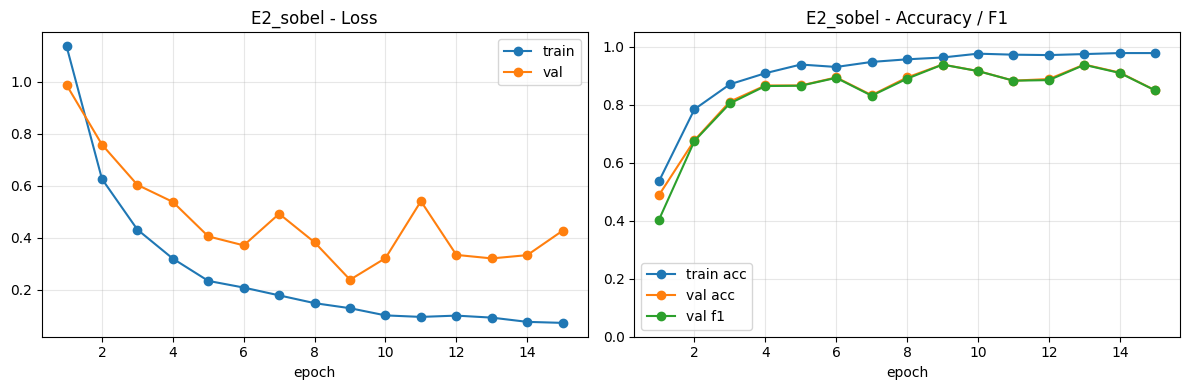

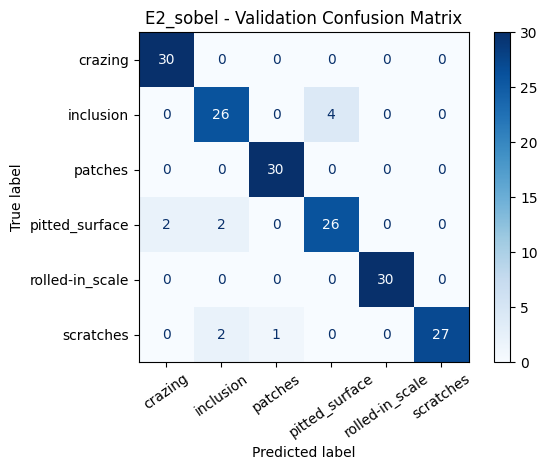

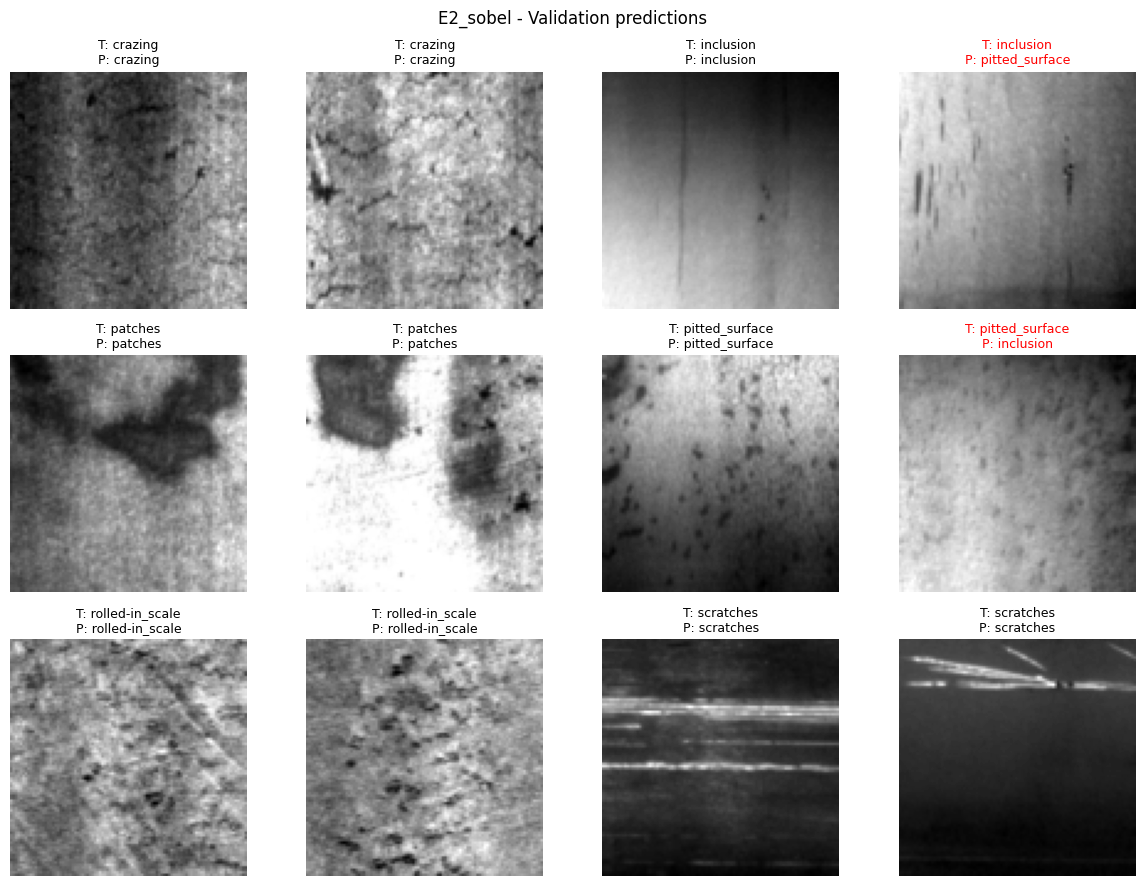

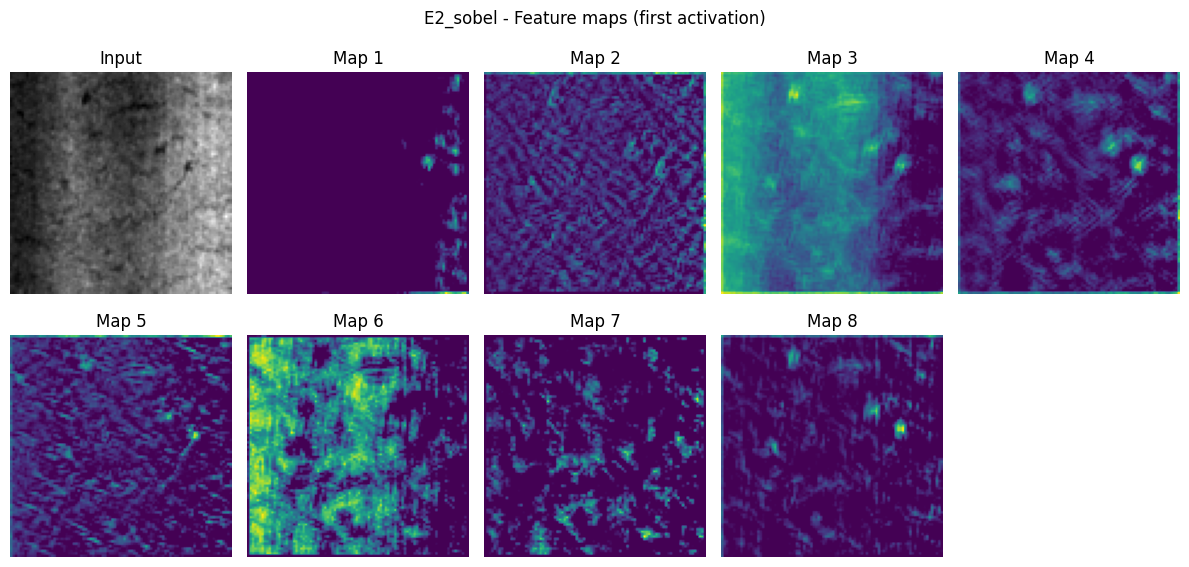

In [ ]:
NORM_2CH = compute_channel_stats(build_transforms(sobel=True), channels=2)

sobel_tf = build_transforms(sobel=True, normalize=NORM_2CH)
train_loader = DataLoader(SteelDefectDataset(train_samples, sobel_tf), batch_size=64, shuffle=True)
val_loader = DataLoader(SteelDefectDataset(val_samples, sobel_tf), batch_size=64)
test_loader = DataLoader(SteelDefectDataset(test_samples, sobel_tf), batch_size=64)

e2_model, _ = train_eval(lambda: BaselineCNN(in_channels=2), train_loader, val_loader, tag="E2_sobel", epochs=15)

## 7. E3 — + Conv 3층 (3×3) + BatchNorm

- 확인 질문: 경계를 더 복잡한 결함 패턴으로 조합하면 좋아지는가?
- 변경: 모델을 `DeepCNN`(Conv 3블록, 채널 8-16-32, **3×3 padding=1**, 각 Conv 뒤 BatchNorm)으로.
  입력(2채널 Sobel)

parameters: 153,758
Epoch 01 | train 1.193/0.543 | val 1.346/0.428 | val_f1 0.385
Epoch 02 | train 0.549/0.824 | val 0.758/0.694 | val_f1 0.688
Epoch 03 | train 0.354/0.887 | val 0.654/0.706 | val_f1 0.704
Epoch 04 | train 0.254/0.919 | val 0.363/0.867 | val_f1 0.861
Epoch 05 | train 0.268/0.904 | val 0.804/0.728 | val_f1 0.703
Epoch 06 | train 0.199/0.938 | val 0.376/0.872 | val_f1 0.870
Epoch 07 | train 0.188/0.940 | val 0.500/0.822 | val_f1 0.812
Epoch 08 | train 0.161/0.951 | val 0.196/0.933 | val_f1 0.933
Epoch 09 | train 0.135/0.953 | val 0.378/0.878 | val_f1 0.875
Epoch 10 | train 0.139/0.958 | val 0.309/0.861 | val_f1 0.856
Epoch 11 | train 0.120/0.960 | val 0.231/0.922 | val_f1 0.921
Epoch 12 | train 0.130/0.960 | val 0.151/0.939 | val_f1 0.938
Epoch 13 | train 0.113/0.964 | val 0.202/0.911 | val_f1 0.907
Epoch 14 | train 0.090/0.971 | val 0.195/0.911 | val_f1 0.909
Epoch 15 | train 0.074/0.981 | val 0.167/0.922 | val_f1 0.922

[E3_conv3_bn] Val Accuracy = 0.9389 | Val Macro F

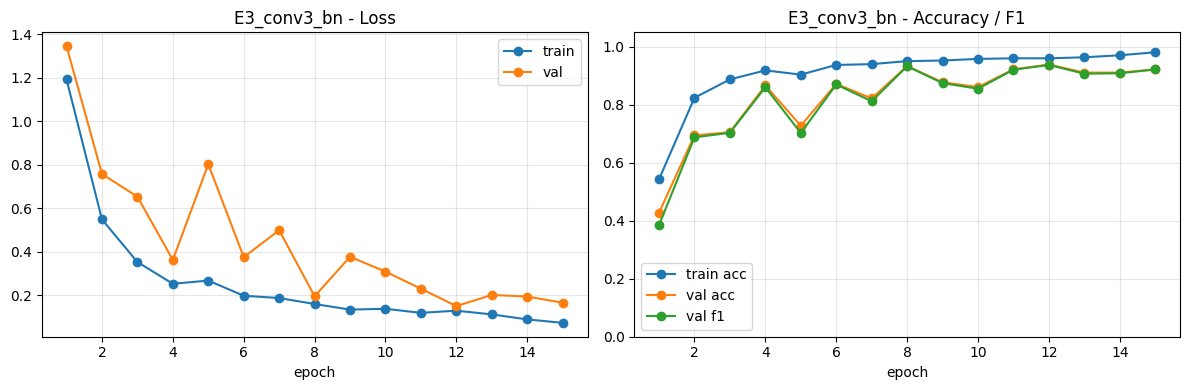

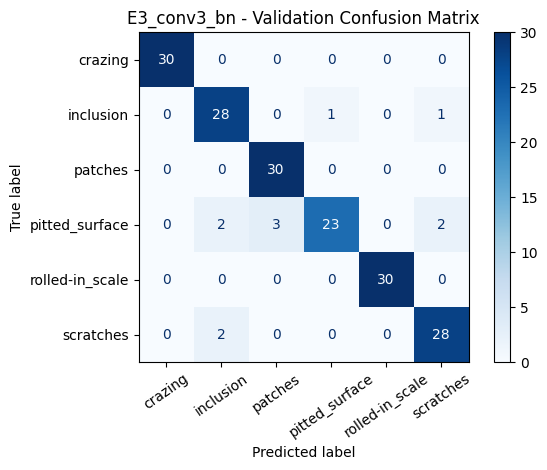

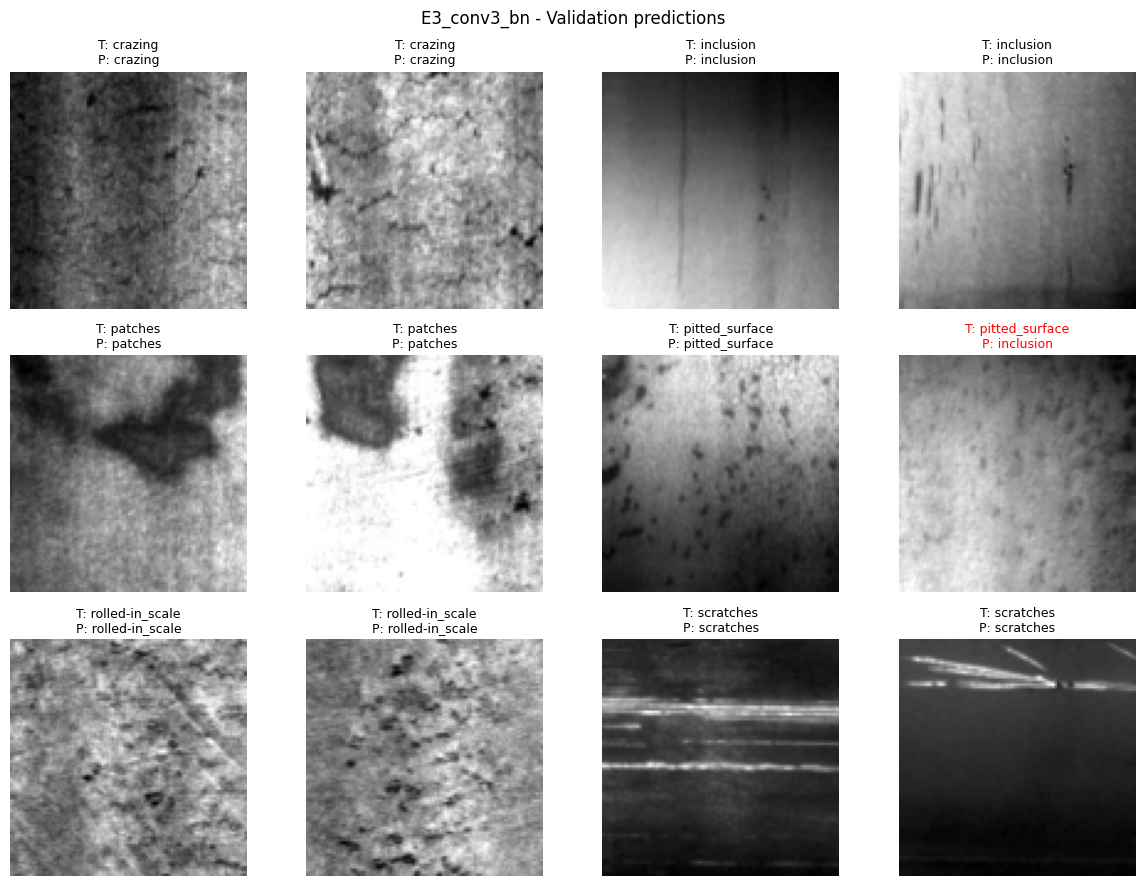

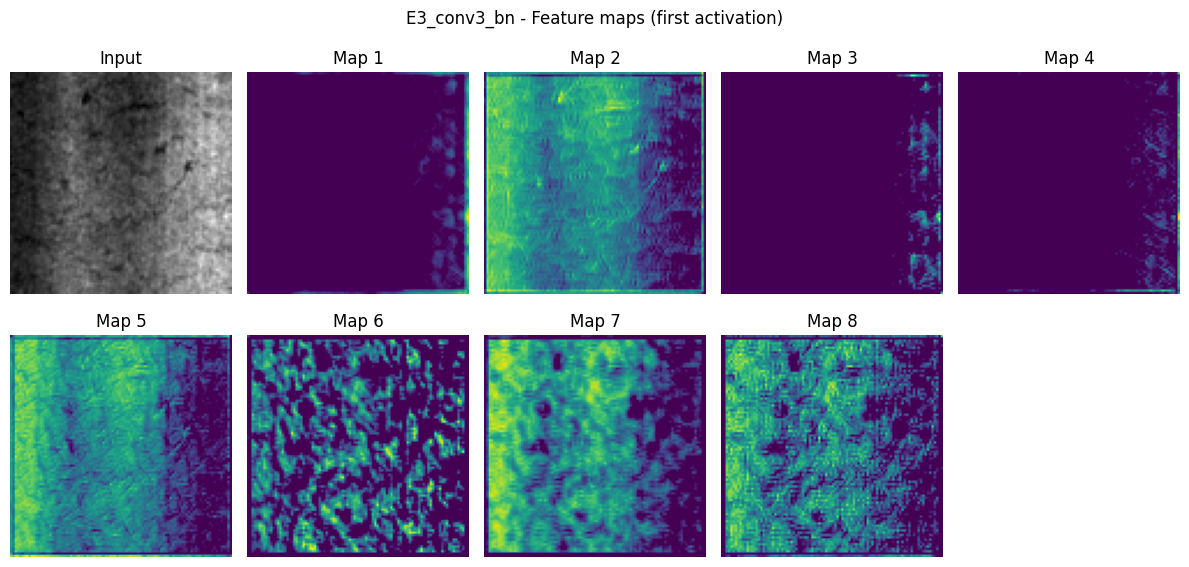

In [50]:
sobel_tf = build_transforms(sobel=True, normalize=NORM_2CH)
train_loader = DataLoader(SteelDefectDataset(train_samples, sobel_tf), batch_size=64, shuffle=True)
val_loader = DataLoader(SteelDefectDataset(val_samples, sobel_tf), batch_size=64)
test_loader = DataLoader(SteelDefectDataset(test_samples, sobel_tf), batch_size=64)

print(f"parameters: {sum(p.numel() for p in DeepCNN(in_channels=2, use_bn=True).parameters()):,}")

e3_model, _ = train_eval(lambda: DeepCNN(in_channels=2, use_bn=True),
                         train_loader, val_loader, tag="E3_conv3_bn", epochs=15)

## 8. 단계별 비교

In [51]:
results_df = pd.DataFrame(RESULTS).set_index("tag")
results_df["delta_f1"] = results_df["val_f1"].diff().fillna(0).round(4)
results_df

,val_acc,val_f1,params,delta_f1
tag,,,,
E0_baseline,0.5556,0.5344,542134,0.0000
E1_normalize,0.7833,0.7765,542134,0.2421
E2_sobel,0.9389,0.9387,542334,0.1622
E3_conv3_bn,0.9389,0.9376,153758,-0.0011
